<a href="https://colab.research.google.com/github/JanviSingh04/Covid-19-detection-using-lung-x-ray/blob/main/pbl_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
eimport tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Paths
BASE_DIR = "/content/drive/MyDrive/COVID-19 Detection Using Lung X-ray Images with Deep Learning"
TRAIN_DIR = BASE_DIR + "/data/train"
VAL_DIR = BASE_DIR + "/data/val"
TEST_DIR = BASE_DIR + "/data/test"

# Model dictionary
models_dict = {
    "resnet50": (ResNet50, resnet_pre),
    "vgg16": (VGG16, vgg_pre),
    "mobilenet": (MobileNetV2, mob_pre),
    "efficientnet": (EfficientNetB0, eff_pre)
}

# Function to create generators
def get_generators(preprocess_fn):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=15,
        zoom_range=0.1,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        color_mode='rgb'
    )

    val_gen = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        color_mode='rgb'
    )

    return train_gen, val_gen


# Loop through models
for name, (ModelClass, preprocess_fn) in models_dict.items():

    print(f"\n Training {name.upper()} model\n")

    train_gen, val_gen = get_generators(preprocess_fn)

    # Class weights
    cw = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_gen.classes),
        y=train_gen.classes
    )
    cw_dict = dict(enumerate(cw))

    # Load base model
    base_model = ModelClass(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    # Freeze layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    # Build model
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=15,
        class_weight=cw_dict
    )

    # Save model
    save_path = BASE_DIR + f"/{name}_covid_model.h5"
    model.save(save_path)
    print(f"{name} model saved")

    print(f"\n Evaluating {name.upper()} model")

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    y_true = test_gen.classes
    y_pred = np.argmax(model.predict(test_gen), axis=1)

    cm = confusion_matrix(y_true, y_pred)
    class_names = list(test_gen.class_indices.keys())

    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{name.upper()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # Classification report
    print(f"\n{name.upper()} Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))


 Training RESNET50 model

Found 949 images belonging to 3 classes.
Found 440 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


KeyboardInterrupt: 

Found 949 images belonging to 3 classes.
Found 440 images belonging to 3 classes.
Found 254 images belonging to 3 classes.

 Training DENSENET121 model

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 424s 13s/step - accuracy: 0.6470 - loss: 0.8110 - val_accuracy: 0.6614 - val_loss: 0.7793
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 258s 9s/step - accuracy: 0.8809 - loss: 0.3259 - val_accuracy: 0.6705 - val_loss: 0.7753
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 259s 9s/step - accuracy: 0.9146 - loss: 0.2413 - val_accuracy: 0.6841 - val_loss: 0.8594
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.9146 - loss: 0.2166 - val_accuracy: 0.6909 - val_loss: 0.9022
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.9452 - loss: 0.1754 - val_accuracy: 0.7023 - val_loss: 0.9162
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 257s 9s/step - accuracy: 0.9473 - loss: 0.1488 - val_accuracy: 0.7045 - val_loss: 0.9923
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━


✅ DenseNet121 model saved at: /content/drive/MyDrive/COVID-19 Detection Using Lung X-ray Images with Deep Learning/densenet121_covid_model.h5

 Evaluating DENSENET121 model

8/8 ━━━━━━━━━━━━━━━━━━━━ 89s 11s/step


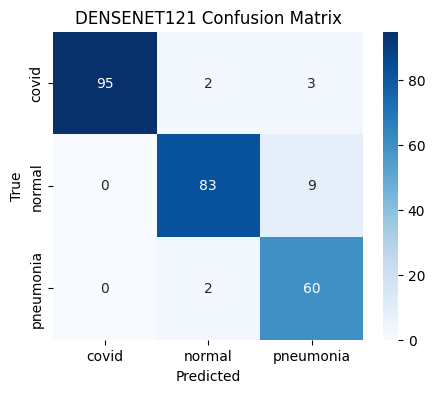


DENSENET121 Classification Report:

              precision    recall  f1-score   support

       covid       1.00      0.95      0.97       100
      normal       0.95      0.90      0.93        92
   pneumonia       0.83      0.97      0.90        62

    accuracy                           0.94       254
   macro avg       0.93      0.94      0.93       254
weighted avg       0.94      0.94      0.94       254



In [ ]:
# Imports
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

# ================= PATHS =================
BASE_DIR = "/content/drive/MyDrive/COVID-19 Detection Using Lung X-ray Images with Deep Learning"
TRAIN_DIR = BASE_DIR + "/data/train"
VAL_DIR   = BASE_DIR + "/data/val"
TEST_DIR  = BASE_DIR + "/data/test"

# ================= DATA GENERATORS =================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# ================= CLASS WEIGHTS =================
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
cw_dict = dict(enumerate(cw))

# ================= MODEL =================
print("\n Training DENSENET121 model\n")

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Build model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ================= TRAIN =================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=cw_dict
)

# ================= SAVE MODEL =================
save_path = BASE_DIR + "/densenet121_covid_model.h5"
model.save(save_path)
print("\n✅ DenseNet121 model saved at:", save_path)

# ================= EVALUATION =================
print("\n Evaluating DENSENET121 model\n")

test_gen.reset()

y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys())

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("DENSENET121 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Classification Report
print("\nDENSENET121 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


✅ Models Loaded Successfully

Found 254 images belonging to 3 classes.
Found 254 images belonging to 3 classes.
Found 254 images belonging to 3 classes.

🔮 Getting predictions from models...

8/8 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 51s 6s/step


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step


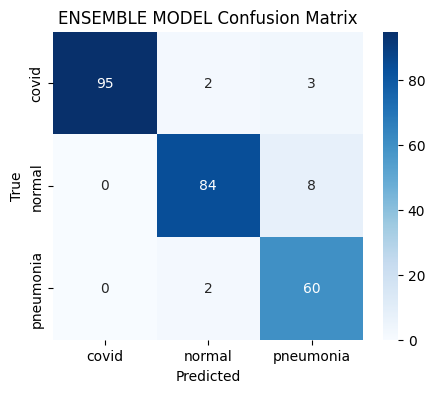


ENSEMBLE MODEL Classification Report:

              precision    recall  f1-score   support

       covid       1.00      0.95      0.97       100
      normal       0.95      0.91      0.93        92
   pneumonia       0.85      0.97      0.90        62

    accuracy                           0.94       254
   macro avg       0.93      0.94      0.94       254
weighted avg       0.95      0.94      0.94       254



In [ ]:
# ================= IMPORTS =================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.densenet import preprocess_input as dense_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre

from sklearn.metrics import confusion_matrix, classification_report

# ================= PATHS =================
BASE_DIR = "/content/drive/MyDrive/COVID-19 Detection Using Lung X-ray Images with Deep Learning"
TEST_DIR = BASE_DIR + "/data/test"

# ================= LOAD MODELS =================
resnet_model = load_model(BASE_DIR + "/resnet50_covid_model.h5")
densenet_model = load_model(BASE_DIR + "/densenet121_covid_model.h5")
efficient_model = load_model(BASE_DIR + "/efficientnet_covid_model.h5")

print("\n✅ Models Loaded Successfully\n")

# ================= CREATE GENERATORS =================
IMG_SIZE = (224,224)
BATCH_SIZE = 32

# IMPORTANT: same images but different preprocessing
resnet_gen = ImageDataGenerator(preprocessing_function=resnet_pre).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

dense_gen = ImageDataGenerator(preprocessing_function=dense_pre).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

eff_gen = ImageDataGenerator(preprocessing_function=eff_pre).flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# ================= RESET GENERATORS =================
resnet_gen.reset()
dense_gen.reset()
eff_gen.reset()

# ================= PREDICTIONS =================
print("\n🔮 Getting predictions from models...\n")

pred_resnet = resnet_model.predict(resnet_gen, verbose=1)
pred_dense = densenet_model.predict(dense_gen, verbose=1)
pred_eff   = efficient_model.predict(eff_gen, verbose=1)

# ================= ENSEMBLE (AVERAGE) =================
final_pred = (pred_resnet + pred_dense + pred_eff) / 3

# Final classes
y_pred = np.argmax(final_pred, axis=1)
y_true = resnet_gen.classes  # same for all

# ================= CONFUSION MATRIX =================
cm = confusion_matrix(y_true, y_pred)
class_names = list(resnet_gen.class_indices.keys())

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("ENSEMBLE MODEL Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ================= REPORT =================
print("\nENSEMBLE MODEL Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))